# Stage 2 — Karst Susceptibility (Mole Creek prototype)

Builds the karst susceptibility layer: karst intensity (from `KCATEGORY`) and exposure type (from `KEXPOSED`/`KCOVERED`/`KINTERSTR`), then cross-checks against 1:25,000 geology as a plausibility check only.

The reclassification logic lives in `src/karst.py`, shared with Stages 3 and 7.

**Field meanings, from the Karst Atlas v3 Data Dictionary** (Sharples 2003):

- `KCATEGORY`, `KEXPOSED`, `KCOVERED`, `KINTERSTR` all share the same ordinal scale: **A** = intensely karstified, **B** = substantially, **C** = partially, **D** = possibly partially, **0** = not karst.
- `KEXPOSED`/`KCOVERED`/`KINTERSTR` classify *which part* of a polygon's karst is exposed/covered/interstratal. They are mutually exclusive per polygon in the Mole Creek data (exactly one is non-zero, or all zero for non-karst polygons).
- Exposed/covered karst is autogenic (recharges from its own rainfall); interstratal karst is not (bounded by non-karst cover, so its hydrology comes from elsewhere). This distinction matters for Stage 3 (hydrological connectivity).

This notebook writes to `karst_mc_susceptibility_EPSG7855.gpkg`. Each stage writes its own output file, so re-running one stage does not overwrite another's columns.

In [1]:
from pathlib import Path
import os
import sys
import geopandas as gpd
import numpy as np
import rasterio
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_karst_susceptibility, rasterize_max
from mapping import add_attribution, add_basemap, data_bounds, finish_map, plot_scores, score_colours, scores_legend

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

karst_mc = gpd.read_file(str(outpath / "karst_mc_EPSG7855.gpkg"))
geology_mc = gpd.read_file(str(outpath / "geology_mc_EPSG7855.gpkg"))

# gpd.clip() in Stage 1 can leave degenerate slivers (line/point) where a
# polygon just grazes the Mole Creek boundary
n_before = len(karst_mc)
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
print(f"Dropped {n_before - len(karst_mc)} degenerate clip artifacts (line/point geometries)")

Dropped 0 degenerate clip artifacts (line/point geometries)


## 2.1 + 2.2 Karst intensity and exposure type

Both via `add_karst_susceptibility()` -- see `src/karst.py` for the exact reclass tables.

Karst intensity distribution:
karst_intensity
0    17
1     4
3    23
4    46
Name: count, dtype: int64

Exposure type distribution:
exposure_type
exposed         45
covered         18
non-karst       17
interstratal    10
Name: count, dtype: int64


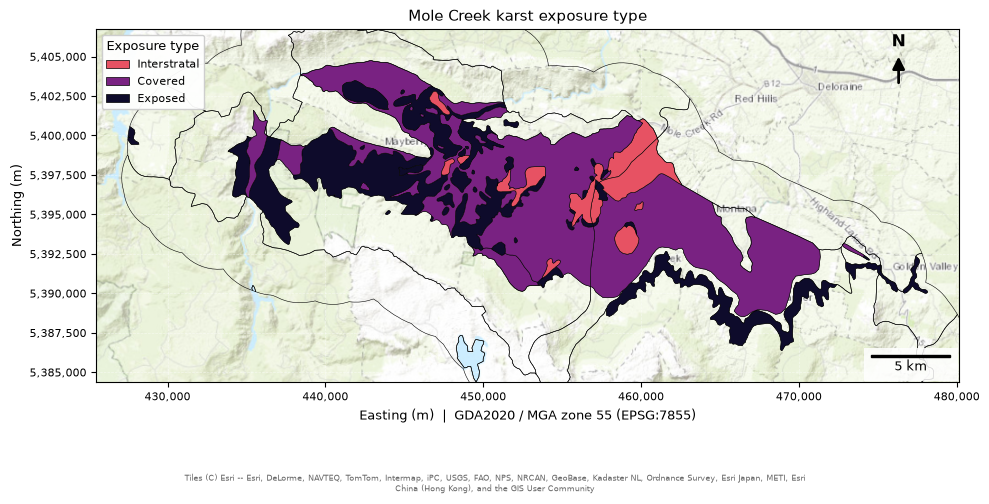

In [2]:
add_karst_susceptibility(karst_mc)

print("Karst intensity distribution:")
print(karst_mc["karst_intensity"].value_counts().sort_index())
print("\nExposure type distribution:")
print(karst_mc["exposure_type"].value_counts())

EXPOSURE_LABELS = ["Non-karst", "Interstratal", "Covered", "Exposed"]
karst_only = karst_mc[karst_mc["karst_intensity"] > 0]
fig, ax = plt.subplots(figsize=(10, 5.6))
add_basemap(ax, karst_only.total_bounds, zoom=11)
karst_mc.plot(ax=ax, color=score_colours(4)[karst_mc["exposure_code"].astype(int)], edgecolor="black",
              linewidth=0.4, zorder=2)
scores_legend(ax, EXPOSURE_LABELS, title="Exposure type")
ax.set_title("Mole Creek karst exposure type", fontsize=11)
finish_map(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## 2.3 Geology cross-check

Does mapped karst coincide with carbonate-described geology? The comparison is broken down by exposure type, because covered and interstratal karst are expected to show low agreement: surface geology mapping shows the cover sediment, not the karst bedrock underneath.

In [3]:
overlay = gpd.overlay(karst_mc[karst_mc["karst_intensity"] > 0], geology_mc, how="intersection")
desc_lower = overlay["description"].fillna("").str.lower()
overlay["is_carbonate"] = desc_lower.str.contains("limestone|dolomite|carbonate") & ~desc_lower.str.contains("non-carbonate|non carbonate")
overlay["area"] = overlay.geometry.area

by_exposure = overlay.groupby("exposure_type").apply(
    lambda g: (g.loc[g["is_carbonate"], "area"].sum() / g["area"].sum()) * 100
)
print("% of overlap area matching carbonate-described surface geology, by exposure type:")
print(by_exposure.round(1))
print("\n(Low % for covered/interstratal is EXPECTED, not an error.)")

% of overlap area matching carbonate-described surface geology, by exposure type:
exposure_type
covered          3.5
exposed         63.4
interstratal     8.4
dtype: float64

(Low % for covered/interstratal is EXPECTED, not an error.)


## 2.4 Rasterise onto the Stage 1 DEM template

Uses `rasterize_max()`, which resolves overlapping polygons by taking the highest value rather than the last one drawn. No polygons with different intensity values overlap in this data, so the result is the same either way.

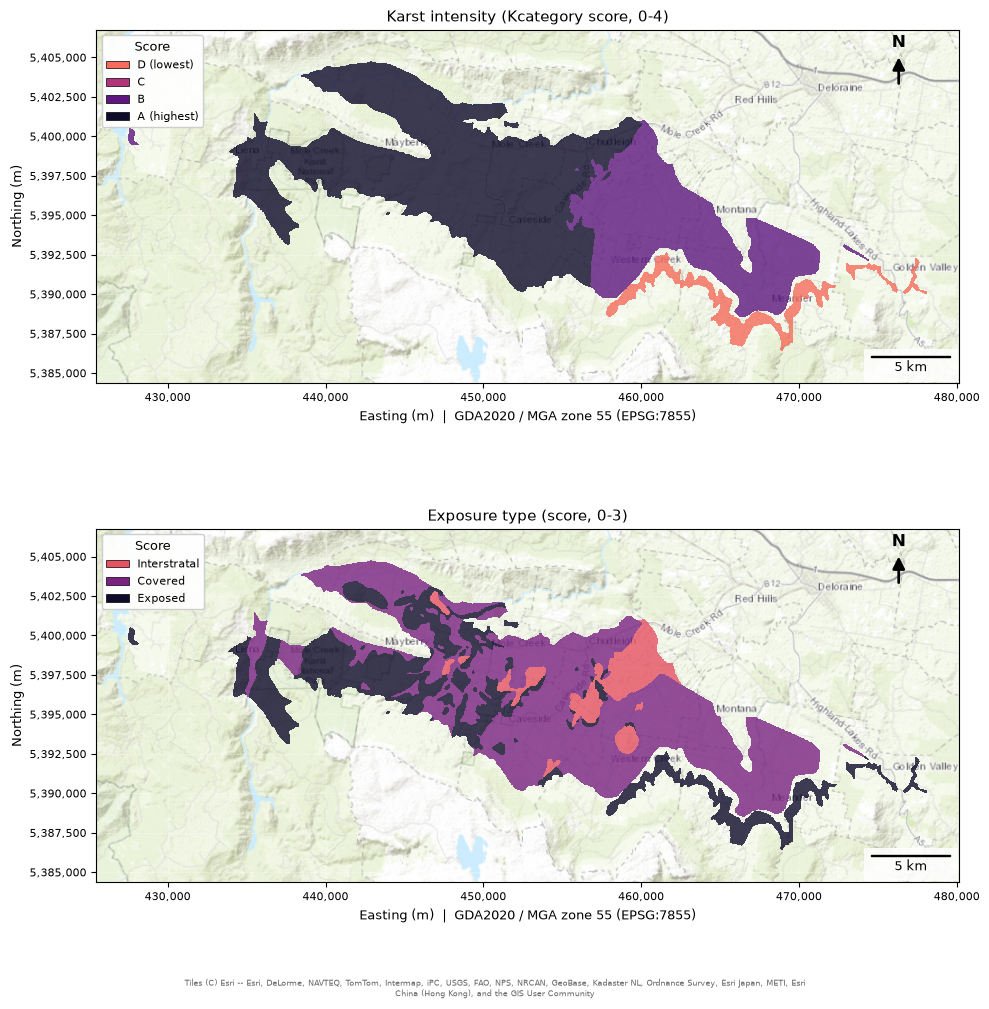

In [4]:
with rasterio.open(str(outpath / "dem_mc_EPSG7855.tif")) as dem_src:
    template_transform = dem_src.transform
    template_shape = (dem_src.height, dem_src.width)
    template_crs = dem_src.crs

intensity_raster = rasterize_max(karst_mc, "karst_intensity", template_shape, template_transform)
exposure_raster = rasterize_max(karst_mc, "exposure_code", template_shape, template_transform)

profile = {
    "driver": "GTiff", "height": template_shape[0], "width": template_shape[1],
    "count": 1, "dtype": "uint8", "crs": template_crs, "transform": template_transform, "nodata": 255,
}
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif", "w", **profile) as dst:
    dst.write(intensity_raster, 1)
with rasterio.open(outpath / "karst_exposure_mc_EPSG7855.tif", "w", **profile) as dst:
    dst.write(exposure_raster, 1)

karst_mc.to_file(outpath / "karst_mc_susceptibility_EPSG7855.gpkg", driver="GPKG")

INTENSITY_LABELS = ["Non-karst", "D (lowest)", "C", "B", "A (highest)"]
bounds = data_bounds(intensity_raster > 0, template_transform)
fig, axes = plt.subplots(2, 1, figsize=(10, 10.5))
for ax, raster, labels, title in [
    (axes[0], intensity_raster, INTENSITY_LABELS, "Karst intensity (Kcategory score, 0-4)"),
    (axes[1], exposure_raster, EXPOSURE_LABELS, "Exposure type (score, 0-3)"),
]:
    add_basemap(ax, bounds, zoom=11)
    plot_scores(ax, raster, template_transform, len(labels))
    scores_legend(ax, labels)
    ax.set_title(title, fontsize=11)
    finish_map(ax)
add_attribution(axes[-1])
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## Stage 2 outputs

- `karst_intensity_mc_EPSG7855.tif` — ordinal karst intensity raster (0-4)
- `karst_exposure_mc_EPSG7855.tif` — exposure type raster (0-3)
- `karst_mc_susceptibility_EPSG7855.gpkg` — Stage 1's data plus `karst_intensity`, `exposure_type`, `exposure_code`

**Next (Stage 3):** hydrological connectivity. `KPROXCATCH` is the primary indicator (it classifies the *downstream karst's category*, not the amount of water or pressure — see data dictionary), cross-checked against DEM-derived flow accumulation.